## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp -r "/content/drive/MyDrive/Aloe_Vera_Dataset" "/content/AloeDataset"


In [ ]:
import os
for folder in os.listdir("/content/AloeDataset"):
    print(folder)


Rot
Discoloration
Aloe_Rust
Mature_Healthy
Young_Healthy
Leaf_Spot
Fungal_Infection


In [ ]:
!pip install split-folders -q
import splitfolders

splitfolders.ratio(
    "/content/AloeDataset",
    output="/content/AloeSplit",
    seed=42,
    ratio=(0.7, 0.15, 0.15)   # train, val, test
)


Copying files: 15584 files [00:28, 547.47 files/s]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix


## 2. Load train / val / test sets

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16  # reduced from 32 to avoid the RAM crash on fine-tuning
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/AloeSplit/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/AloeSplit/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/AloeSplit/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False   # keep order so predictions line up with true labels
)

class_names = train_ds.class_names
print(class_names)


Found 10907 files belonging to 7 classes.
Found 2336 files belonging to 7 classes.
Found 2341 files belonging to 7 classes.
['Aloe_Rust', 'Discoloration', 'Fungal_Infection', 'Leaf_Spot', 'Mature_Healthy', 'Rot', 'Young_Healthy']


In [ ]:
labels = []
for _, batch_labels in train_ds:
    labels.extend(batch_labels.numpy())

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(1.0760655090765587), 1: np.float64(0.5777318713914932), 2: np.float64(0.5911012356384132), 3: np.float64(0.5866501721170396), 4: np.float64(2.2259183673469387), 5: np.float64(22.259183673469387), 6: np.float64(2.2259183673469387)}


In [ ]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


## 3. Build the model (MobileNetV2 transfer learning)

In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
outputs = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,272,071 (8.67 MB)

 Trainable params: 11,527 (45.03 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 4. Train (frozen base, then fine-tune)

In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.5)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/20
682/682 ━━━━━━━━━━━━━━━━━━━━ 641s 740ms/step - accuracy: 0.4859 - loss: 1.1714 - val_accuracy: 0.6173 - val_loss: 1.0316 - learning_rate: 0.0010
Epoch 2/20
682/682 ━━━━━━━━━━━━━━━━━━━━ 570s 632ms/step - accuracy: 0.5808 - loss: 0.8227 - val_accuracy: 0.6383 - val_loss: 0.9292 - learning_rate: 0.0010
Epoch 3/20
682/682 ━━━━━━━━━━━━━━━━━━━━ 613s 686ms/step - accuracy: 0.5982 - loss: 0.7833 - val_accuracy: 0.6507 - val_loss: 0.9000 - learning_rate: 0.0010
Epoch 4/20
682/682 ━━━━━━━━━━━━━━━━━━━━ 534s 575ms/step - accuracy: 0.6105 - loss: 0.7329 - val_accuracy: 0.6665 - val_loss: 0.8840 - learning_rate: 0.0010
Epoch 5/20
682/682 ━━━━━━━━━━━━━━━━━━━━ 647s 696ms/step - accuracy: 0.6136 - loss: 0.7407 - val_accuracy: 0.6460 - val_loss: 0.8916 - learning_rate: 0.0010
Epoch 6/20
682/682 ━━━━━━━━━━━━━━━━━━━━ 566s 619ms/step - accuracy: 0.6171 - loss: 0.7148 - val_accuracy: 0.6657 - val_loss: 0.8980 - learning_rate: 0.0010
Epoch 7/20
682/682 ━━━━━━━━━━━━━━━━━━━━ 637s 722ms/step - accura

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

checkpoint_path = "/content/drive/MyDrive/Aloe_Disease_Model_checkpoint.keras"
fine_tune_callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.5),
    ModelCheckpoint(checkpoint_path, save_best_only=True, monitor="val_accuracy")
]

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks
)


Epoch 1/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 601s 692ms/step - accuracy: 0.5847 - loss: 0.7983 - val_accuracy: 0.6601 - val_loss: 0.8810 - learning_rate: 1.0000e-05
Epoch 2/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 575s 671ms/step - accuracy: 0.6101 - loss: 0.7161 - val_accuracy: 0.6807 - val_loss: 0.8025 - learning_rate: 1.0000e-05
Epoch 3/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 672s 774ms/step - accuracy: 0.6202 - loss: 0.6915 - val_accuracy: 0.6892 - val_loss: 0.7818 - learning_rate: 1.0000e-05
Epoch 4/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 612s 697ms/step - accuracy: 0.6362 - loss: 0.6567 - val_accuracy: 0.7025 - val_loss: 0.7549 - learning_rate: 1.0000e-05
Epoch 5/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 609s 688ms/step - accuracy: 0.6444 - loss: 0.6377 - val_accuracy: 0.7085 - val_loss: 0.7500 - learning_rate: 1.0000e-05
Epoch 6/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 583s 688ms/step - accuracy: 0.6554 - loss: 0.6100 - val_accuracy: 0.7183 - val_loss: 0.7242 - learning_rate: 1.0000e-05
Epoch 7/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 

## 5. Training curves (accuracy & loss)

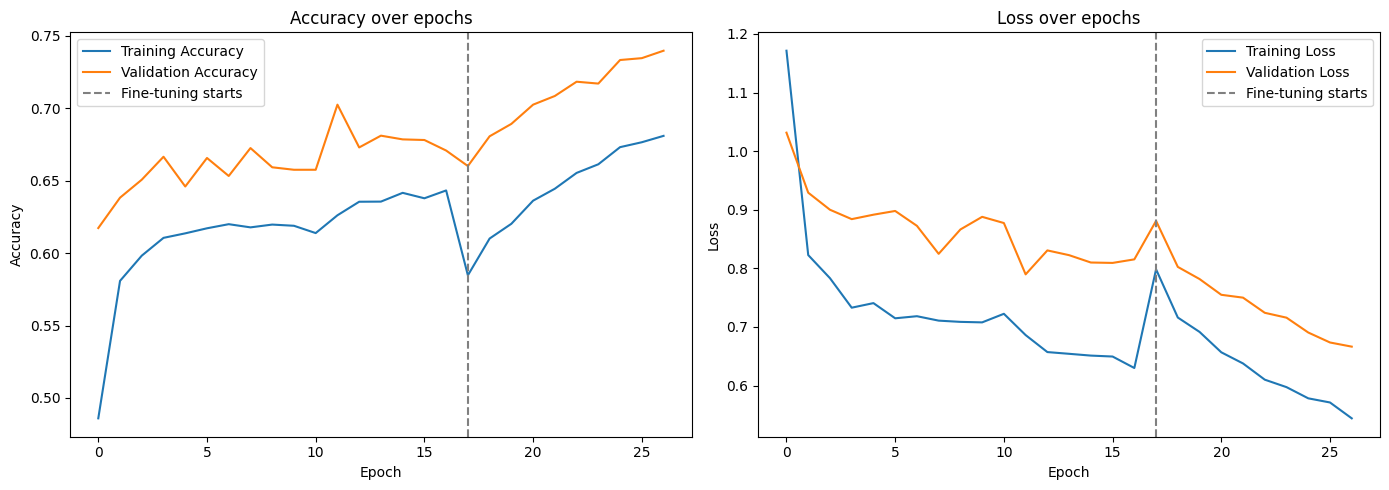

In [ ]:
acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

fine_tune_start = len(history.history['accuracy'])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(fine_tune_start, linestyle='--', color='gray', label='Fine-tuning starts')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(fine_tune_start, linestyle='--', color='gray', label='Fine-tuning starts')
plt.title('Loss over epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Aloe_Disease_Model_training_curves.png', dpi=150)
plt.show()


## 6. Evaluate on the UNSEEN test set
This is the set the model never saw during training or fine-tuning, and was never used by any callback.

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Unseen test accuracy: {test_acc*100:.2f}%")
print(f"Unseen test loss: {test_loss:.4f}")


147/147 ━━━━━━━━━━━━━━━━━━━━ 90s 606ms/step - accuracy: 0.7480 - loss: 0.6280
Unseen test accuracy: 74.80%
Unseen test loss: 0.6280


In [ ]:
test_probs = model.predict(test_ds)
test_pred_labels = np.argmax(test_probs, axis=1)
test_true_labels = np.concatenate([y.numpy() for _, y in test_ds])

print(classification_report(test_true_labels, test_pred_labels, target_names=class_names))


147/147 ━━━━━━━━━━━━━━━━━━━━ 98s 663ms/step
                  precision    recall  f1-score   support

       Aloe_Rust       0.56      0.75      0.64       311
   Discoloration       0.81      0.61      0.70       579
Fungal_Infection       0.75      0.77      0.76       566
       Leaf_Spot       0.73      0.74      0.73       570
  Mature_Healthy       0.97      0.96      0.96       150
             Rot       1.00      1.00      1.00        15
   Young_Healthy       0.92      0.96      0.94       150

        accuracy                           0.75      2341
       macro avg       0.82      0.83      0.82      2341
    weighted avg       0.76      0.75      0.75      2341



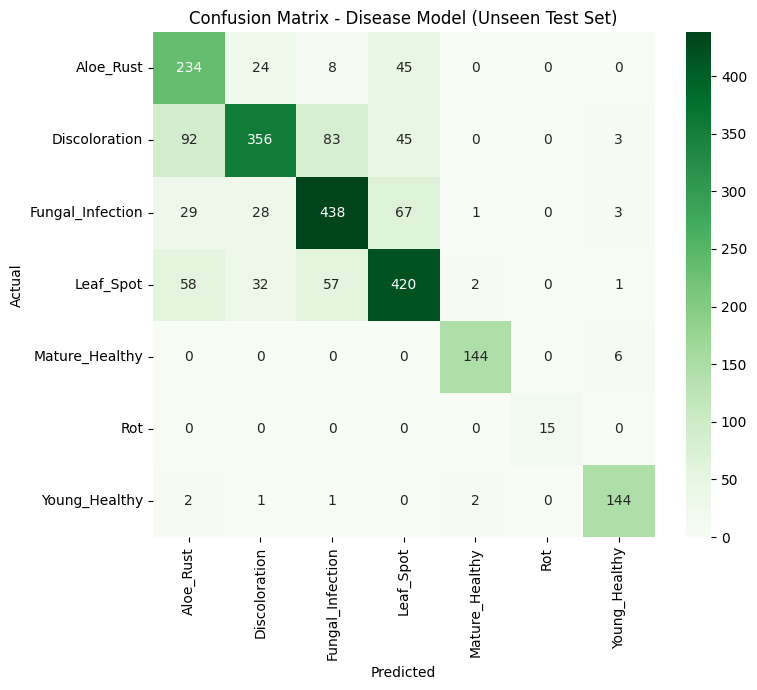

In [ ]:
cm = confusion_matrix(test_true_labels, test_pred_labels)

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Disease Model (Unseen Test Set)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Aloe_Disease_Model_TEST_confusion_matrix.png', dpi=150)
plt.show()


## 7. Predict on a single image

In [ ]:
def predict_disease(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    probs = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(probs)
    predicted_class = class_names[pred_idx]
    confidence = probs[pred_idx] * 100

    if predicted_class == "Young_Healthy":
        recommendation = "EXPORT QUALITY"
    elif predicted_class == "Mature_Healthy":
        recommendation = "LOCAL MARKET"
    elif predicted_class == "Discoloration":
        recommendation = "NOT EXPORT GRADE - NEEDS INSPECTION"
    else:
        recommendation = "REJECTED - DISEASE DETECTED"

    print("=" * 50)
    print("Prediction :", predicted_class)
    print(f"Confidence : {confidence:.2f}%")
    print("Recommendation :", recommendation)
    print("=" * 50)

    return {"predicted_class": predicted_class, "confidence": round(float(confidence), 2), "recommendation": recommendation}

# Example:
# predict_disease('/content/AloeSplit/test/Rot/some_image.jpg')


## 8. Save the model

In [ ]:
model.save("/content/Aloe_Improved_Model.keras")
!cp "/content/Aloe_Improved_Model.keras" "/content/drive/MyDrive/"


NameError: name 'model' is not defined